In [86]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.express as px
import plotly.io as pio
from datetime import datetime
import numpy as np

In [87]:
def apply_custom_style():
    """Configura o look-and-feel global do projeto."""
    px.defaults.template = "seaborn"
    #px.defaults.color_continuous_scale = "Viridis"
    pio.templates[px.defaults.template]['layout']['hovermode'] = 'x unified'
    
    pio.templates["seaborn"].update({
        "layout": {
            "title_x": 0.5,            # Títulos centralizados
            "hovermode": "x unified",  # Hover profissional
            "xaxis": dict(automargin=True),
            "yaxis": dict(automargin=True)
        }
    })

In [88]:
apply_custom_style()

In [89]:
df = pd.read_csv('data/processed/dados_projeto_limpos.csv')

df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce').astype('Int64')

## **Usando Plotly**

### **Gráfico de Linha**

In [90]:
def plot_performance_line_interactive(data, x_col, y_col, title=None, group_col=None, n=None):
    ts = datetime.now().strftime("%Y%m%d-%H%M%S")
    # Se n for fornecido, filtra os top n antes de plotar
    if n and group_col:
        # 1. Identifica os grupos baseado na performance total/média
        top_groups = data.groupby(group_col)[y_col].mean().nlargest(n).index
        # 2. Filtra o dataframe original mantendo a granularidade
        data = data[data[group_col].isin(top_groups)]
        # 3. Agrupa POR DATA e GRUPO para garantir que a linha seja contínua
        data = data.groupby([x_col, group_col])[y_col].mean().reset_index()

    elif n:
        data = data.groupby([x_col, group_col])[y_col].mean().reset_index()
        top_n = data.sort_values(by=y_col, ascending=False).head(n)#
        data = top_n[[x_col, y_col]]#
    else:
        data = data.groupby([x_col, group_col])[y_col].mean().reset_index()
        n = data[y_col].nunique()#
        top_n = data.sort_values(by=y_col, ascending=False).head(n)#
    
    fig = px.line(data, x=x_col, y=y_col, color=group_col, markers=True, title=title)
    fig.update_xaxes(tickformat="d") # Formata o eixo x para mostrar apenas os anos como inteiros
    fig.update_layout(
        #xaxis=dict(automargin=True),
        xaxis_title=x_col.title().replace('_', ' '),#
        xaxis_rangeslider_visible=True, #Mostra Slider de seleção horizontal
        xaxis_anchor="y",# Trava o eixo X ao eixo Y
            
        yaxis_title=y_col.title().replace('_', ' '),#
        #yaxis_autorange=True,#
        yaxis_domain=[0.15, 1],#
        yaxis_anchor="x",     # Trava o eixo Y ao eixo X
        yaxis_side="left",    # Garante que ele fique fixo à esquerda

        legend_title=group_col.title().replace('_', ' '),#
    )

    filename = f"plot_line_{title}_{ts}"    
    os.makedirs('data/figures', exist_ok=True)
    
    fig.write_html(f"data/figures/{filename}.html")
    
    
    return fig


In [91]:
plot_performance_line_interactive(df, 'release_year', 'aa_intelligence_index', title='Intelligence Index Over Time (Top 20)', group_col='generic_model_name', n=30)

In [92]:
plot_performance_line_interactive(df, 'release_year', 'speed_per_dollar', title='Speed per Dollar on Open Source X Private Models (Top 20 Average)', group_col='is_open_source', n=20)

In [93]:
plot_performance_line_interactive(df, 'release_year', 'intelligence_per_dollar', title='Intelligence per Dollar on Open Source X Private Models (Top 20 average)', group_col='is_open_source')

In [94]:
plot_performance_line_interactive(df, 'release_year', 'intelligence_per_dollar', title='Intelligence per Dollar on models', group_col='generic_model_name',n=10)

In [95]:
plot_performance_line_interactive(df, 'release_year', 'intelligence_per_dollar', title='Intelligence per Dollar on models', group_col='generic_model_name',n=20)

### **Gráficos de barra (Barras Horizontais e Verticais)**

In [96]:
def plot_performance_barh_interactive(data, x_col, y_col, title=None, group_col=None, n=None, calculate='sum'):
    ts = datetime.now().strftime("%Y%m%d-%H%M%S")
    data = data.sort_values(by=y_col, ascending=True)
    if calculate not in ('mean', 'sum'):
        raise ValueError("calculate deve ser 'mean' ou 'sum'")
    
    # 1. Agrega todo o conjunto de dados primeiro para não perder precisão no cálculo
    if group_col:
        # Se tem grupo, agrupamos por X e pelo Grupo
        data_agg = data.groupby([x_col, group_col], dropna=False)[y_col].agg(calculate).reset_index()
    else:
        # Agrupamento simples por X
        data_agg = data.groupby(x_col, dropna=False)[y_col].agg(calculate).reset_index()

    # 2. Determina quem são os Top N baseados no valor agregado final
    if n:
        # Agrupamos novamente por X para garantir que estamos pegando os N melhores 'modelos' 
        # (independente de como os grupos internos se dividem)
        top_indices = data_agg.groupby(x_col)[y_col].sum().nlargest(n).index
        data_agg = data_agg[data_agg[x_col].isin(top_indices)]

    # 3. Ordenação para o gráfico (Garante que o maior fique no topo no gráfico de barras)
    data_agg = data_agg.sort_values(by=y_col, ascending=True)

    # 4. Criação do gráfico (se for horizontal, x e y se invertem)
    fig = px.bar(data_agg, x=y_col, y=x_col, color=group_col, title=title, orientation='h',text_auto=True)

    fig.update_layout(
    
        xaxis=dict(automargin=True),
        xaxis_title=y_col.title().replace('_', ' '),

        yaxis=dict(automargin=True),
        yaxis_title=x_col.title().replace('_', ' '), # Reforça a ordem visual
        yaxis_tickformat='d'
        
    )

    filename = f"plot_barh_{title}"    
    os.makedirs('data/figures', exist_ok=True)    
    fig.write_html(f"data/figures/{filename}.html")

    return fig


In [97]:
def plot_performance_bar_interactive(data, x_col, y_col, title=None, group_col=None, n=None, calculate='sum'):
    ts = datetime.now().strftime("%Y%m%d-%H%M%S")

    data = data.sort_values(by=y_col, ascending=True).convert_dtypes()
    
    if calculate not in ('mean', 'sum'):
        raise ValueError("calculate deve ser 'mean' ou 'sum'")
    
    # 1. Agrega TODO o conjunto de dados primeiro para não perder precisão no cálculo
    if group_col:
        # Se tem grupo, agrupamos por X e pelo Grupo
        data_agg = data.groupby([x_col, group_col], dropna=False)[y_col].agg(calculate).reset_index()
    else:
        # Agrupamento simples por X
        data_agg = data.groupby(x_col, dropna=False)[y_col].agg(calculate).reset_index()

    # 2. Determina quem são os Top N baseados no valor agregado final
    if n:
        # Agrupamos novamente por X para garantir que estamos pegando os N melhores 'modelos' 
        # (independente de como os grupos internos se dividem)
        top_indices = data_agg.groupby(x_col)[y_col].sum().nlargest(n).index
        data_agg = data_agg[data_agg[x_col].isin(top_indices)]

    # 3. Ordenação para o gráfico (Garante que o maior fique no topo no gráfico de barras)
    data_agg = data_agg.sort_values(by=y_col, ascending=True)

    # 4. Criação do gráfico (se for horizontal, x e y se invertem)
    fig = px.bar(data_agg, x=x_col, y=y_col, color=group_col, title=title, text_auto=True)

    fig.update_layout(
        xaxis=dict(automargin=True),
        xaxis_title=y_col.title().replace('_', ' '),
        yaxis=dict(automargin=True),
        yaxis_title=x_col.title().replace('_', ' '), # Reforça a ordem visual
        xaxis_tickformat="d",
    )

    filename = f"plot_bar_{title}"    
    os.makedirs('data/figures', exist_ok=True)
    fig.write_html(f"data/figures/{filename}.html")
    return fig


In [98]:
def plot_performance_histogram_interactive(data, x_col, y_col, title=None, group_col=None, n=None):
    # 1. Filtro Top N (Precisa ser feito antes, pois o Plotly não corta o DF sozinho)
    if n:
        # Encontra os N maiores valores por categoria
        top_categories = data.groupby(x_col)[y_col].max().nlargest(n).index
        data = data[data[x_col].isin(top_categories)]

    # 2. Criação do Histograma (usando histfunc='max')
    fig = px.histogram(
        data, 
        x=y_col, 
        y=x_col, 
        color=group_col, 
        title=title,
        orientation='h',
        histfunc='max',  # Define a lógica do cálculo como o maior valor
        barmode='group', # Garante que as barras fiquem lado a lado se houver grupos
        text_auto='.2s'   # Formata o número automaticamente
    )

    # 3. Ajustes de layout e ordenação
    fig.update_layout(
        yaxis={'categoryorder': 'total ascending'}, # Ordena o eixo Y pelo valor total da barra
        xaxis_title=y_col.replace('_', ' ').title(),
        yaxis_title=x_col.replace('_', ' ').title(),
        bargap=0.2
    )

    # 4. Salvamento
    os.makedirs('data/figures', exist_ok=True)
    filename = f"hist_max_{title if title else 'plot'}_{datetime.now().strftime('%H%M%S')}.html"
    fig.write_html(f"data/figures/{filename}")

    return fig

In [99]:
plot_performance_barh_interactive(df, 'clean_model_name', 'intelligence_per_dollar', title='Intelligence Index per model',calculate='mean', n=20)

In [100]:
plot_performance_bar_interactive(df, 'is_open_source', 'intelligence_per_dollar', title='Open Source X Propietary comparison - Intelligence Index', n=20, calculate='mean')

In [101]:
plot_performance_bar_interactive(df, 'release_year', 'aa_intelligence_index', title='Intelligence Index per Release Year', n=20, calculate='mean')

In [103]:
plot_performance_histogram_interactive(df, 'provider', 'intelligence_per_dollar', n=10)

In [104]:
plot_performance_histogram_interactive(df, 'provider', 'intelligence_per_dollar', n=10)

In [105]:
plot_performance_histogram_interactive(df, 'clean_model_name', 'intelligence_per_dollar', n=10)

In [106]:
plot_performance_histogram_interactive(df, 'provider', 'speed_per_dollar', n=10)

In [107]:
plot_performance_histogram_interactive(df, 'clean_model_name', 'speed_per_dollar', n=10)

### **Mapa de calor de correlação**

In [ ]:
#creating a correlation graph with plotly:
def plot_correlation_heatmap(data, cols, title=None):

    ts = datetime.now().strftime("%Y%m%d-%H%M%S")

    corr = data[cols].corr()
    fig = px.imshow(
        corr,
        text_auto=True,
        aspect="auto",
        title=title,
        color_continuous_scale='RdBu',
        zmin=-1,
        zmax=1
    )
    fig.update_layout(xaxis_title="Métricas", yaxis_title="Métricas", xaxis=dict(automargin=True), yaxis=dict(automargin=True),)
    # paleta de cores do azul pro vermelho, passando por branco no meio
    fig.update_traces(colorbar_title='Correlação')
    # atualizar nomes de eixo de forma consistente
    tick_labels = [col.replace('_', ' ').title() for col in cols]
    tick_vals = list(range(len(cols)))
    fig.update_xaxes(tickvals=tick_vals, ticktext=tick_labels)
    fig.update_yaxes(tickvals=tick_vals, ticktext=tick_labels)
    fig.update_layout(hovermode='closest')
    
    filename = f"plot_correlation_{title}"    
    os.makedirs('data/figures', exist_ok=True)
    fig.write_html(f"data/figures/{filename}.html")

    return fig

In [ ]:
plot_correlation_heatmap(df, ['release_year', 'aa_intelligence_index', 'time_to_first_answer_s','blended_cost_usd_per_1m', 'price_performance_ratio', ], title='Correlação entre Métricas de Desempenho e lançamento')

### **Gráfico de dispersão filtrável por release_year**

In [ ]:
#creating a scatter plot with plotly:
def plot_scatter_interactive(data, x_col, y_col, title=None, group_col=None, n=None, filter=False):
    """Plota um gráfico de dispersão interativo com métodos customizáveis usando Plotly.
    args:
        data (pd.DataFrame): DataFrame contendo os dados a serem plotados.
        x_col (str): Nome da coluna para o eixo x.
        y_col (str): Nome da coluna para o eixo y.
        title (str, opcional): Título do gráfico. Padrão é None.
        group_col (str, opcional): Nome da coluna para agrupar por cor. Padrão é None.
        n (int, opcional): Número de top grupos a serem plotados. Padrão é None (todos os grupos).
        filter (bool, opcional): Se True, adiciona um filtro por ano de lançamento (release_year) usando um slider. Padrão é False.
    returns:
        plotly.graph_objs._figure.Figure: Objeto da figura do gráfico de dispersão.
    """

    ts = datetime.now().strftime("%Y%m%d-%H%M%S")

    # Garantir que a coluna 'release_year' seja do tipo numérico para evitar problemas no filtro
    data=data.copy().dropna(subset=['release_year'])

    # Se n for fornecido, filtra os top n antes de plotar
    if group_col and n:
        top_groups = data.groupby(group_col)[y_col].mean().nlargest(n).index
        data = data[data[group_col].isin(top_groups)]
    elif n:
        data = data.sort_values(by=y_col, ascending=False).head(n)

    # Para garantir que as categorias sejam ordenadas de forma consistente, criamos um dicionário de ordens de categoria baseado na média de y_col para cada grupo, ordenado de forma decrescente. Isso ajuda a manter uma ordem lógica nas legendas e cores do gráfico.
    category_orders = {}
    if group_col:
        group_order = data.groupby(group_col)[y_col].mean().sort_values(ascending=False).index.tolist()
        category_orders[group_col] = group_order
    # Agora, ao criar o gráfico de dispersão, passamos o parâmetro category_orders para garantir que as categorias sejam ordenadas de forma consistente com a média de y_col. Isso é especialmente útil para gráficos de dispersão onde a cor ou o agrupamento é baseado em categorias, garantindo que a legenda e as cores sejam apresentadas de forma lógica e fácil de interpretar.
    fig = px.scatter(
        data,
        x=x_col,
        y=y_col,
        color=group_col,
        title=title,
        category_orders=category_orders,
        labels={
            x_col: x_col.replace('_', ' ').title(),
            y_col: y_col.replace('_', ' ').title()
        },
    )

    # Configurações adicionais para melhorar a aparência do gráfico
    fig.update_traces(marker=dict(size=8, opacity=0.8))
    if group_col:
        fig.update_layout(
            legend_title=group_col.replace('_', ' ').title(),
            legend_traceorder='normal'
        )

    # Se filter for True e a coluna 'release_year' estiver presente, adiciona um slider para filtrar os dados por ano de lançamento
    if filter and 'release_year' in data.columns:
        # Ordena os anos de lançamento e cria um botão para cada ano
        years = sorted(data['release_year'].dropna().astype(int).unique())
        buttons = []
        
        for year in years:
            
            if group_col:
                x_vals = []
                y_vals = []
                
                for trace in fig.data: # Itera sobre cada traço (grupo) no gráfico
                    mask = (
                        (data[group_col] == trace.name) & # Filtra os dados para o grupo atual
                        (data['release_year'].astype(int) == year) # Filtra os dados para o ano atual
                    )
                    x_vals.append(data.loc[mask, x_col].tolist()) # Adiciona os valores de x para o grupo e ano atuais
                    y_vals.append(data.loc[mask, y_col].tolist()) # Adiciona os valores de y para o grupo e ano atuais
            
            else:
                mask = data['release_year'].astype(int) == year
                x_vals = [data.loc[mask, x_col].tolist()]
                y_vals = [data.loc[mask, y_col].tolist()]
            
            # Adição do botão para filtrar os dados por ano de lançamento
            buttons.append(dict(
                label=str(year),
                method='update', #O método 'update' é usado para atualizar os dados do gráfico com base no filtro aplicado.
                args=[
                    {'x': x_vals, 'y': y_vals}, #Atualiza os dados do gráfico com os valores filtrados para o ano selecionado.
                    {'title': f"{title or ''} - {year}"} # Atualiza o título do gráfico com o ano selecionado.
                ]
            ))

        # Adiciona um botão para mostrar todos os dados
        fig.update_layout(
            updatemenus=[dict(
                active=len(buttons) - 1,
                buttons=buttons,
                x=-0.1,
                #y=1.20,
                xanchor='right',
                yanchor='top'
            )],
            hovermode='closest'
        )

    filename = f"plot_scatter_{title}"    
    os.makedirs('data/figures', exist_ok=True)
    
    fig.write_html(f"data/figures/{filename}.html")

    return fig

In [108]:
plot_scatter_interactive(df, 'blended_cost_usd_per_1m', 'aa_intelligence_index', group_col='provider', n=20, filter=True, title='Intelligence Index vs Cost per 1M Tokens with Year Filter')

In [109]:
plot_scatter_interactive(df, 'blended_cost_usd_per_1m', 'aa_coding_index', group_col='clean_model_name', n=20, filter=True, title='Coding Index vs Cost per 1M Tokens with Year Filter')

In [ ]:
def plot_value_for_money(data):
    try:
        # Filtrar a base: Remover linhas que estão com o Preço ou a Inteligência em branco (NaN)
        df_clean = data.dropna(subset=['blended_cost_usd_per_1m', 'composite_benchmark'])

        # ==========================================
        # FASE DE ANÁLISE E GRÁFICO (TEMA A)
        # ==========================================

        # Filtrar dados para garantir que o custo seja positivo para a escala logarítmica
        df_plotted = df_clean[df_clean['blended_cost_usd_per_1m'] > 0].copy()

        # Calcular uma métrica de custo-benefício (Inteligência / Custo)
        # Adicionar um pequeno valor ao custo para evitar divisão por zero se houver algum custo 0
        df_plotted['cost_benefit_ratio'] = df_plotted['composite_benchmark'] / (df_plotted['blended_cost_usd_per_1m'])

        # Identificar os 5 melhores modelos por custo-benefício APÓS filtrar por custo positivo
        top_5_models = df_plotted.nlargest(5, 'cost_benefit_ratio')

        # Separar as variáveis X (Custo) e Y (Inteligência) usando numpy do DataFrame filtrado
        x = df_plotted['blended_cost_usd_per_1m'].values
        y = df_plotted['composite_benchmark'].values

        # Calcular a correlação estatística básica usando numpy
        correlacao = np.corrcoef(x, y)[0, 1]
        print(f"Modelos analisados: {len(df_plotted)}")
        print(f"Correlação entre Custo e Inteligência: {correlacao:.2f}")

        # Debug: Print data ranges
        print(f"X (Custo) min: {x.min()}, X max: {x.max()}")
        print(f"Y (Inteligência) min: {y.min()}, Y max: {y.max()}")
        print(f"Top 5 X (Custo) min: {top_5_models['blended_cost_usd_per_1m'].min()}, Top 5 X max: {top_5_models['blended_cost_usd_per_1m'].max()}")
        print(f"Top 5 Y (Inteligência) min: {top_5_models['composite_benchmark'].min()}, Top 5 Y max: {top_5_models['composite_benchmark'].max()}")

        # Configurar e criar o Gráfico de Dispersão (Scatter Plot)
        fig, ax = plt.subplots(figsize=(15, 9)) # Aumentar o tamanho para acomodar os rótulos e evitar o warning
        ax.scatter(x, y, alpha=0.6, color='teal', edgecolors='black', label='Outros Modelos')

        # Plotar os 5 melhores modelos em destaque
        ax.scatter(top_5_models['blended_cost_usd_per_1m'],
                   top_5_models['composite_benchmark'],
                   color='red', s=150, edgecolors='white', zorder=5, label='Top 5 Custo-Benefício') # Tamanho maior e cor distinta

        # Adicionar rótulos aos top 5 modelos
        for i, row in top_5_models.iterrows():
            ax.text(row['blended_cost_usd_per_1m'] * 1.1, # Ajustar a posição x ligeiramente para legibilidade
                    row['composite_benchmark'],
                    row['model_name'],
                    fontsize=9, ha='left', va='center', color='darkred', weight='bold')

        # Usar escala logarítmica no Eixo X porque os preços variam drasticamente
        # (de $0.01 a mais de $100 por 1 milhão de tokens)
        ax.set_xscale('log')

        # Adicionar títulos e rótulos bem explicativos
        ax.set_title('Análise: Custo vs. Inteligência dos Modelos de IA', fontsize=16, pad=15)
        ax.set_xlabel('Custo Combinado (USD por 1 Milhão de Tokens) - Escala Logarítmica', fontsize=12)
        ax.set_ylabel('Nota de Inteligência (Composite Benchmark)', fontsize=12)

        # Adicionar linhas de grade para facilitar a visualização no trabalho
        ax.grid(True, which="both", linestyle="--", alpha=0.5)

        # Adicionar legenda
        ax.legend()

        # Evitar que os textos fiquem cortados e salvar a imagem
        os.makedirs('data/figures', exist_ok=True)
        plt.savefig('data/figures/custo_vs_inteligencia.png', bbox_inches='tight')
    
    except Exception as e:
        print(e)


Modelos analisados: 295
Correlação entre Custo e Inteligência: 0.29
X (Custo) min: 0.02, X max: 35.0
Y (Inteligência) min: 4.1, Y max: 92.4
Top 5 X (Custo) min: 0.025, Top 5 X max: 0.094
Top 5 Y (Inteligência) min: 28.04, Top 5 Y max: 53.1


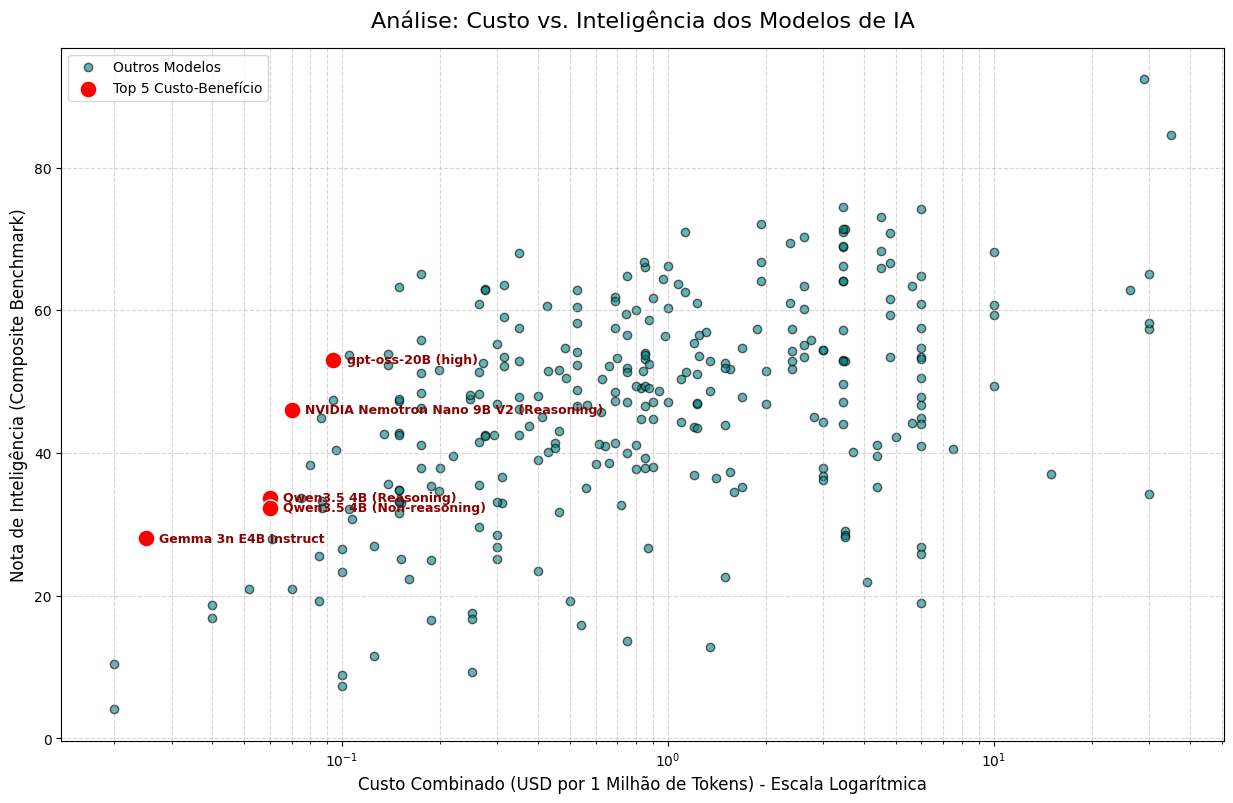

In [ ]:
plot_value_for_money(df)

## **Plotando gráfico de área baseado em frequência de ocorrências (nesse caso modelos de linguagem)**

In [ ]:
#Gráfico de área
def plot_area_freq_interactive(data, x_col, group_col,sort_by='x',slider=True):
    #ts = datetime.now().strftime("%Y%m%d-%H%M%S")
    x_col_clean = x_col.replace('_',' ').title()
    group_col_clean = group_col.replace('_',' ').title()
    title=f"Quantidade de modelos por {x_col_clean} separados por {group_col_clean}"
    data_counts = data.groupby([x_col, group_col]).size().reset_index(name='Count')
    match sort_by:
        case 'x':
            data_counts = data_counts.sort_values(by=x_col).fillna(0)
        case 'y':
            data_counts = data_counts.sort_values(by=['Count',x_col], ascending=True).fillna(0)
        case _:
            raise Exception("The sort_by parameter must be 'x' or 'y'.")
        
    max_y = data_counts.groupby(x_col)['Count'].sum().max()
    fig = px.area(data_counts,x=x_col, y='Count', color=group_col, title=title, labels={'Count': 'Total de Ocorrências ', x_col: x_col_clean, group_col : group_col_clean}, animation_frame=group_col if slider else None)

    fig.update_xaxes(tickformat='%d')
    fig.update_yaxes(range=[0,max_y])
    fig.update_traces(showlegend=False if slider else True)
    fig.update_layout(showlegend=False if slider else True)

    
    filename = f"plot_area_{title}"    
    os.makedirs('data/figures', exist_ok=True)
    
    fig.write_html(f"data/figures/{filename}.html")

    return fig


In [ ]:
plot_area_freq_interactive(df, "release_year", group_col='pricing_tier',sort_by='x', slider=False)

In [ ]:
plot_area_freq_interactive(df, "release_year", group_col='pricing_tier',sort_by='x', slider=True)

## **Donut Personalizado**

In [ ]:
#criar uma função de plotagem de rosca com a biblioteca seaborn:
def plot_donut_interactive(data, measure, categories):
    ts = datetime.now().strftime("%Y%m%d-%H%M%S")
    data_grouped = data.groupby(categories)[measure].nunique().reset_index()
    data_group = data_grouped.sort_values(categories)
    print(data_grouped)
    measure_clean = measure.replace('_',' ').title()
    categories_clean = categories.replace('_',' ').title()
    title = f'{measure_clean} X {categories_clean}'
    fig = px.pie(data_grouped, values=measure, names=categories, title=title, hole=0.5)
    fig.update_traces(textposition='outside', textinfo='label+percent', marker=dict(line=dict(color='#fff', width=3)))

    filename = f"plot_donut_{title}"    
    os.makedirs('data/figures', exist_ok=True)
    fig.write_html(f"data/figures/{filename}.html")


    return fig

In [ ]:
plot_donut_interactive(df,'model_name','is_open_source',)

   is_open_source  model_name
0           False         151
1            True         302


In [ ]:
plot_donut_interactive(df,'model_name','is_open_source')

   is_open_source  model_name
0           False         151
1            True         302


In [112]:
plot_donut_interactive(df,'blended_cost_usd_per_1m','is_open_source',)

   is_open_source  blended_cost_usd_per_1m
0           False                       42
1            True                       90


In [117]:
plot_donut_interactive(df,'model_name','pricing_tier')

  pricing_tier  model_name
0       Budget         111
1         Free          16
2          Mid         152
3      Premium          27
4        Ultra           9
5      Unknown         138
